In [6]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

In [7]:
#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score


import torch 
import torch.nn as nn

In [8]:
df = pd.read_csv("Post_EDA_data.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,y,Customer_history,loan_age_months,months_since_earliest_credit_line,current_balance_ratio,payment_progress_ratio
0,12000.0,12000.0,12000.0,36 months,7.97,375.88,A,A5,10+ years,OWN,...,NaN,NaN,NaN,N,1,7762,38,293,0.000000,1.000000
1,32000.0,32000.0,32000.0,36 months,11.99,1062.71,B,B5,10+ years,MORTGAGE,...,123.08000,6189.66,1062.71,N,1,4383,38,182,0.192465,0.807535
2,40000.0,40000.0,40000.0,60 months,15.05,952.65,C,C4,9 years,MORTGAGE,...,NaN,NaN,NaN,N,1,5632,38,223,0.559423,0.440577
3,16000.0,16000.0,16000.0,36 months,7.97,501.17,A,A5,5 years,RENT,...,NaN,NaN,NaN,N,1,6301,38,245,0.153464,0.846536
4,33000.0,33000.0,33000.0,36 months,7.21,1022.12,A,A3,< 1 year,MORTGAGE,...,177.96231,10197.78,59.68,N,0,4292,38,179,0.299184,0.700816


In [9]:
df.shape

(2029952, 131)

In [10]:
#self.Q1_ saves the learned threshold from training so it can be consistently applied to new data.
class OutlierFlaggerv2(BaseEstimator, TransformerMixin):
    #Sklearn pipeline uses both x and y so thus we add y=None
    def fit(self,X, y=None):
        #To keep track of the columns
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        self.feature_names_in_ = list(X.columns)
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        #Return the capsulated info obtained
        return self

    def transform(self,X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        X.columns = X.columns.astype(str)
        lower = self.Q1 -  1.5*self.IQR
        upper = self.Q3 +  1.5*self.IQR
        flags = ((X < lower) |(X>upper)).astype(int)
        #We keep the original feature and add a new column to capture outlier information, not replace it.

        flags.columns = [str(col) + "_outlier" for col in X.columns]
        
        return flags
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            #Store the input features in a variable, then to a list
            input_features = self.feature_names_in_
        input_features = [str(col) for col in input_features]
        outlier_names = [col + "_outlier" for col in input_features]
        return np.array(outlier_names, dtype=object)

In [11]:
class Missing_val_dropper(BaseEstimator,TransformerMixin):
    def __init__(self, threshold = 50.0):
        self.threshold = threshold

    def fit(self,X,y=None):
        #learns the columns to drop
        X = pd.DataFrame(X).copy()

        #Missing percent vector that holds the missing percentage indexed by the col names
        missing_percent = X.isna().mean() * 100

        #Columns with  >= threshold missigness
        self.columns_to_drop = missing_percent[missing_percent >= self.threshold].index.tolist()

        self.feature_names = X.columns.tolist()
        return self
    
    def transform(self,X):
        #actually drops the columns
        X = pd.DataFrame(X).copy()
        return X.drop(columns=self.columns_to_drop,errors="ignore")

## Cross Validation

In [12]:
#Divide from X and y
X = df.drop("y", axis=1)
y= df["y"]

In [13]:
#Dropped after seeing it was data leakage
X.drop(["recoveries","collection_recovery_fee"],axis=1, inplace=True)
#recoveries is the money recovered after a loan has defaulted.
#collection_recovery_fee is the cost charged for collecting that recovered money.


In [14]:
leakage_cols = [
    "out_prncp",
    "out_prncp_inv",
    "total_rec_prncp",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "debt_settlement_flag",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int"
]
X.drop(leakage_cols,axis=1,inplace=True)

In [15]:
#Hardship flag removal since it indicates if the borrower is haviung trouble paying
X.drop("hardship_flag",axis=1,inplace=True)

In [16]:
#subsample a subset of the data
X_sub = X.sample(n=200000, random_state=42)
y_sub = y.loc[X_sub.index]

In [17]:
# train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub,
    test_size=0.30,
    random_state=42,
    stratify=y_sub
)

#validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

'''
Ideally we end up with
70% train
15% validation
15% test
'''

'\nIdeally we end up with\n70% train\n15% validation\n15% test\n'

In [18]:
numerical_columns = X.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns = X.select_dtypes(include=["object","category"]).columns

In [19]:
#Sample the numerical columns only from the training data
X_sample = X_train.sample(n=5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

In [20]:
#Only numerical columns
X_num_sample = X_sample[numerical_columns]
X_num_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,Customer_history,loan_age_months,months_since_earliest_credit_line,current_balance_ratio,payment_progress_ratio
1308177,5000.0,5000.0,5000.0,17.57,179.69,20000.0,35.29,0.0,735.0,739.0,...,NaN,NaN,NaN,NaN,NaN,3103,68,170,0.000000,1.000000
690673,37600.0,37600.0,37600.0,7.21,1164.60,325000.0,12.62,1.0,770.0,774.0,...,NaN,NaN,NaN,NaN,NaN,7884,25,284,0.000000,1.000000
568761,9000.0,9000.0,9000.0,10.08,290.75,33000.0,27.71,0.0,675.0,679.0,...,NaN,NaN,NaN,NaN,NaN,5844,28,220,0.453481,0.546519
1425531,28000.0,28000.0,27900.0,14.46,658.21,121400.0,5.07,0.0,755.0,759.0,...,NaN,NaN,NaN,NaN,NaN,6453,56,268,0.000000,1.000000
1588854,28000.0,28000.0,28000.0,22.45,780.52,110000.0,14.87,5.0,665.0,669.0,...,NaN,NaN,NaN,NaN,NaN,6664,54,273,0.000000,0.378837


## PCA & t-nse

In [21]:
#Consruct the numerical pipeline and fit transform
#Try standard scaler and Robust
num_only_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler())
])

X_num_processed = num_only_pipe.fit_transform(X_num_sample)

In [22]:
#Do PCA on the trimmed data
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_num_processed)

In [23]:
#Apply t-nse
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

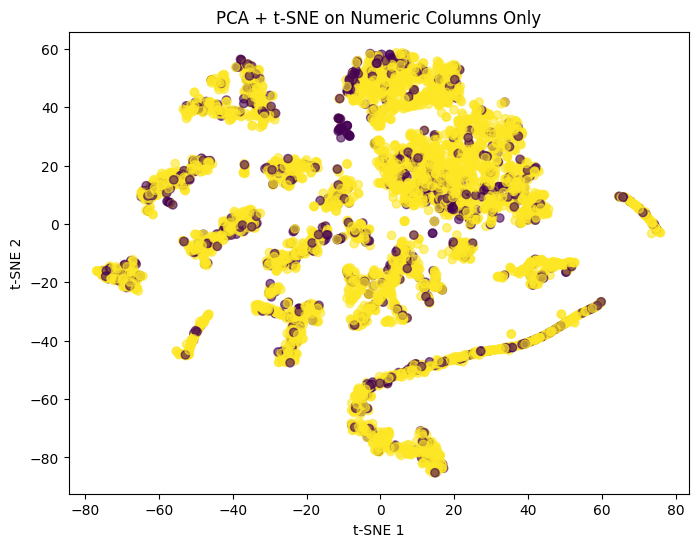

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, alpha=0.6)
plt.title("PCA + t-SNE on Numeric Columns Only")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## ---------------------------

## Pipeline creation & post-transformation evaluation & Univariate variable selection

Block of code below assesses the multicollinearity between 2 numerical independent variables. If it is above a certain threshold we remove the one with less mutual information

In [25]:
#Version to fit into the pipeline
class CorrelationFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)

        corr_matrix = X.corr(numeric_only=True).abs()

        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper = corr_matrix.where(mask)

        #Use the set to not collect duplicates
        columns_to_drop = set()

        for col in upper.columns:
            for row in upper.index:
                if upper.loc[row,col] > self.threshold and pd.notna(upper.loc[row, col]):
                    #mutual info needs to be 2d inputted
                    mi_row = mutual_info_classif(X[[row]],y,random_state=45)
                    mi_col = mutual_info_classif(X[[col]],y,random_state=45)
                    #reminder larger values means stronger association
                    if mi_row[0] >= mi_col[0]:
                        columns_to_drop.add(col)
                    else:
                        columns_to_drop.add(row)
        self.columns_to_drop = list(columns_to_drop)
        self.feature_names = list(X.columns)

        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


In [26]:
def cramers_V(x,y):
    '''
    Here we calculate the Cramer's V to asses the strength of association between 2 nominal variables
    '''
    table =pd.crosstab(x,y)
    #Extract only the chi-square statistics
    chi2=chi2_contingency(table)[0]
    n = table.sum().sum()
    r,k = table.shape
    return np.sqrt(chi2 / (n*(min(r,k) -1)))

In [27]:
#Version to fit into the pipeline
class CategoricalFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)
        self.feature_names = list(X.columns)

        to_drop = set()

        for i in range(len(self.feature_names)):
            for j in range(i + 1, len(self.feature_names)):
                col1 = self.feature_names[i]
                col2 = self.feature_names[j]
                
                v = cramers_V(X[col1], X[col2])
                
                if v > self.threshold:
                    # compare usefulness with target using mutual info
                    x1_encoded = pd.factorize(X[col1])[0].reshape(-1, 1)
                    x2_encoded = pd.factorize(X[col2])[0].reshape(-1, 1)

                    mi1 = mutual_info_classif(x1_encoded, y, discrete_features=True, random_state=45)
                    mi2 = mutual_info_classif(x2_encoded, y, discrete_features=True, random_state=45)
                    
                    if mi1[0] >= mi2[0]:
                        to_drop.add(col2)
                    else:
                        to_drop.add(col1)
        self.columns_to_drop= list(to_drop)
        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


## Variable Selection via tree-based model

## Model selection

Here is the list of models, that are a candidate pool of models
* (FFN) Feed forward Nueral Network
* Logistic regression
* Xg Boost
* random forest

Maybe change from standard scaler to robust scaler

In [28]:
def model_summary(fitted_model, X_val,y_val,model_name):
    #Predicted probabilities for DV of 0
    y_probs = fitted_model.predict_proba(X_val)[:,0]
    y_pred = fitted_model.predict(X_val)

    class_report = classification_report(y_val,y_pred)
    # ROC values
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    # AUC
    auc = roc_auc_score(1-y_val, y_probs)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    #Baseline
    plt.plot([0, 1], [0, 1], linestyle='--') 
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of DV=0")
    plt.legend()
    plt.show()


    print(class_report)
    print(f"current model auc:{auc:3f}")
    print(f"current model name:{model_name}")

In [29]:
numerical_columns_train = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns_train = X_train.select_dtypes(include=["object","category"]).columns

In [30]:
def Youden_threshold(fitted_model, X_val, y_val):
    
    # Probability of original class 0
    y_probs = fitted_model.predict_proba(X_val)[:, 0]

    # Treat original class 0 as the positive class
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    j_threshold = thresholds[best_idx]

    print(f"Youden threshold for class 0: {j_threshold}")
    
    # Predict class 0 if probability of class 0 is above threshold
    y_pred_changed = np.where(y_probs >= j_threshold, 0, 1)
   
    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_changed))

    return j_threshold

In [31]:
def f1_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # F1 score for class 0
        score = f1_score(y_val, y_pred, pos_label=0)
        f1_scores.append(score)

    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"F1 optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [32]:
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

to_float = FunctionTransformer(
    lambda x: x.astype(np.float32)
)

In [33]:
models_of_interest =[
("Logistic Regression",LogisticRegression(max_iter=1000)),
("Random Forest",RandomForestClassifier(n_estimators=200,random_state=42)),
("XG Boost",XGBClassifier())
]

Research Goal: Can we predict whether a LendingClub loan is in good standing based on the borrower’s current financial and credit profile?

## Preprocessing & feature selection pipeline

In [34]:
numerical_train_columns = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_train_columns = X_train.select_dtypes(include=["object","category"]).columns

In [35]:
#Pipeline that is built with the preprocessing, and feature selection

#Categorical pipeline
cat_pip = Pipeline([
    ("imputer",SimpleImputer(strategy='constant',fill_value="missing")),
    ("feature_selector",CategoricalFeatureSelector(threshold=0.80)),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

#Numerical Pipeline
numerical_pip = FeatureUnion([
    ("scaled_num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])),

    ("outlier_flags", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("outlier_flag", OutlierFlaggerv2())
    ])),

    ("missing_flags", MissingIndicator(features="missing-only"))
])

#ColumnTransformer
preprocessing = ColumnTransformer(
    transformers=[
        ("cat", cat_pip, Cat_train_columns),
        ("num", numerical_pip, numerical_train_columns),
    ],
    remainder="passthrough"
)

In [36]:
baseline_pipeline = Pipeline([
    ("process",preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector",SelectFromModel(
        RandomForestClassifier(n_estimators=1000,random_state=42), threshold='mean'
    )),
    ("model", LogisticRegression(max_iter=1000))
])

## -----------------------------------------------------------

# Baseline with the added missing_val_droppers

In [37]:


categorical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("cat_selector", CategoricalFeatureSelector(threshold=0.80)),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

numerical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier", OutlierFlaggerv2()),
    ("scaler", RobustScaler())
])

In [38]:
preprocessing = ColumnTransformer([
    ("cat", categorical_pipeline, Cat_columns_train),
    ("num", numerical_pipeline, numerical_columns_train)
], remainder="passthrough")

In [39]:
baseline_pipeline = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=1000, random_state=42),
        threshold="mean"
    )),
    ("model", LogisticRegression(max_iter=1000))
])

In [42]:
#Baseline with PCA

baseline_pipeline_pca = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=1000, random_state=42),
        threshold="mean"
    )),
    ("pca", PCA(n_components=30, random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [38]:
baseline_pipeline.fit(X_train, y_train)

,steps,"[('process', ...), ('corr_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


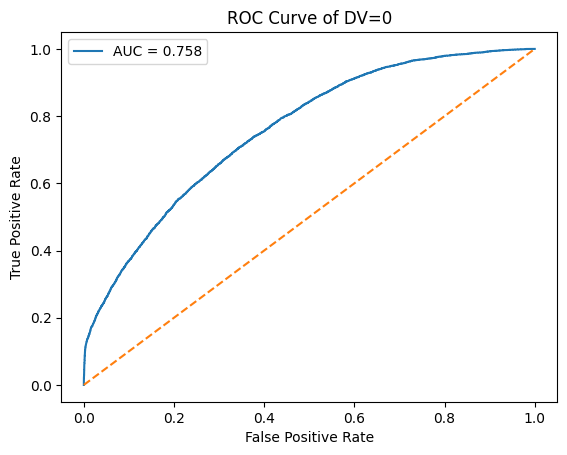

              precision    recall  f1-score   support

           0       0.77      0.14      0.23      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.85     30000
   macro avg       0.81      0.56      0.58     30000
weighted avg       0.84      0.85      0.81     30000

current model auc:0.758429
current model name:base


In [39]:
model_summary(baseline_pipeline, X_val, y_val, "base")

## -----------------------------------------------------------

In [ ]:


param_dist_ml = [
    {
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": randint(100, 800),
        "model__max_depth": [5, 10, 20, None],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model": [XGBClassifier(random_state=42, eval_metric="logloss")],
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(2, 8),
        "model__learning_rate": uniform(0.01, 0.2)
    }
]

ml_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_dist_ml,
    n_iter=5,          # tries 20 random combinations total
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

ml_search.fit(X_train, y_train)

In [ ]:


param_dist_lr = [
    {
        "model": [LogisticRegression(max_iter=1000)],
        "model__C": uniform(0.01, 10),
        "model__class_weight": [None, "balanced"]
    }
]

lr_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_dist_lr,
    n_iter=5, 
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

lr_search.fit(X_train, y_train)

## Pipeline name extraction

In [ ]:


# ============================================================
# 1. Get best fitted pipeline pieces
# ============================================================

best_pipe = lr_search.best_estimator_

process = best_pipe.named_steps["process"]
corr_selector = best_pipe.named_steps["corr_selector"]
tree_selector = best_pipe.named_steps["tree_selector"]
best_model = best_pipe.named_steps["model"]


# ============================================================
# 2. Get categorical feature names manually
# ============================================================

cat_pipeline = process.named_transformers_["cat"]
cat_selector = cat_pipeline.named_steps["feature_selector"]
ohe = cat_pipeline.named_steps["ohe"]

cat_cols = np.array(Cat_train_columns, dtype=object)

columns_to_drop = getattr(cat_selector, "columns_to_drop", [])

print("Categorical columns originally:")
print(cat_cols)

print("\nCategorical columns dropped by selector:")
print(columns_to_drop)

# If your selector stored dropped columns as integer positions
if len(columns_to_drop) > 0 and isinstance(columns_to_drop[0], (int, np.integer)):
    kept_cat_cols = np.delete(cat_cols, columns_to_drop)

# If your selector stored dropped columns as names
elif len(columns_to_drop) > 0 and isinstance(columns_to_drop[0], str):
    kept_cat_cols = np.array([
        col for col in cat_cols
        if col not in columns_to_drop
    ], dtype=object)

# If nothing was dropped
else:
    kept_cat_cols = cat_cols

print("\nCategorical columns kept:")
print(kept_cat_cols)

# Now this should match the number of columns OneHotEncoder saw
cat_feature_names = ohe.get_feature_names_out(kept_cat_cols)

print("\nNumber of OHE categorical features:")
print(len(cat_feature_names))

print("\nFirst 20 categorical feature names:")
print(cat_feature_names[:20])


# ============================================================
# 3. Get numeric feature names manually
# ============================================================

num_cols = np.array(numerical_train_columns, dtype=object)

scaled_num_names = np.array([
    f"scaled_num__{col}" for col in num_cols
], dtype=object)

outlier_flag_names = np.array([
    f"outlier_flags__{col}_outlier" for col in num_cols
], dtype=object)

# MissingIndicator is inside the FeatureUnion
num_pipeline = process.named_transformers_["num"]
missing_indicator = num_pipeline.transformer_list[2][1]

missing_cols = num_cols[missing_indicator.features_]

missing_flag_names = np.array([
    f"missing_flags__{col}_missing" for col in missing_cols
], dtype=object)


# ============================================================
# 4. Combine all feature names after preprocessing
# ============================================================

feature_names_after_process = np.concatenate([
    cat_feature_names,
    scaled_num_names,
    outlier_flag_names,
    missing_flag_names
])

X_processed = process.transform(X_train)

print("\nShape after preprocessing:")
print(X_processed.shape)

print("\nNumber of feature names created:")
print(len(feature_names_after_process))

assert X_processed.shape[1] == len(feature_names_after_process), \
    "Feature names do not match processed data shape."

print("\nFeature names match processed data shape.")


# ============================================================
# 5. Get features after CorrelationFeatureSelector
# ============================================================

corr_columns_to_drop = getattr(corr_selector, "columns_to_drop", [])

print("\nColumns dropped by correlation selector:")
print(corr_columns_to_drop)

if len(corr_columns_to_drop) > 0 and isinstance(corr_columns_to_drop[0], str):
    features_after_corr = np.array([
        feature for feature in feature_names_after_process
        if feature not in corr_columns_to_drop
    ], dtype=object)

elif len(corr_columns_to_drop) > 0 and isinstance(corr_columns_to_drop[0], (int, np.integer)):
    features_after_corr = np.delete(feature_names_after_process, corr_columns_to_drop)

else:
    features_after_corr = feature_names_after_process

print("\nNumber of features after correlation selector:")
print(len(features_after_corr))


# ============================================================
# 6. Get final features after tree selector
# ============================================================

tree_mask = tree_selector.get_support()

final_features = features_after_corr[tree_mask]

print("\nNumber of final features used by model:")
print(len(final_features))

final_features_df = pd.DataFrame({
    "final_feature": final_features
})

display(final_features_df)


# ============================================================
# 7. Feature importance / coefficients
# ============================================================

if hasattr(best_model, "coef_"):
    importance_df = pd.DataFrame({
        "feature": final_features,
        "coefficient": best_model.coef_[0]
    })

    importance_df["abs_importance"] = importance_df["coefficient"].abs()

    importance_df = importance_df.sort_values(
        "abs_importance",
        ascending=False
    )

elif hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": final_features,
        "importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

else:
    importance_df = pd.DataFrame({
        "feature": final_features
    })

print("\nTop final features:")
display(importance_df.head(30))

NameError: name 'lr_search' is not defined

## Slightly more complex model selection

In [1]:
from sklearn.metrics import make_scorer, f1_score

#to make a score that is f1, score but to detect it on the minority cl asss 0
f1_class_0 = make_scorer(f1_score, pos_label=0)

In [ ]:
#%pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [71]:
pipe = Pipeline(steps=[
    ('preprocess', preprocessing),
    ('sampler', 'passthrough'),
    ('model', LogisticRegression())
])

In [72]:
param_distributions_ml = [
    #Each dictionary value is for each model set up, like for example each differnt versions of Logistic regression are based on the different model penalties, and not all can use other model penalties
    
    # Random Forest
    {   "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        'sampler': [
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [RandomForestClassifier(random_state=42)],
        'model__n_estimators': [100, 300, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__max_features': ['sqrt', 'log2'],
        'model__class_weight': ['balanced']
    },

    # XGBoost
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        'sampler': [
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )],
        'model__n_estimators': [100, 300, 500,800],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0]
    }
]

In [73]:
ml_search_v2 = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions_ml,
    n_iter=7,
    scoring=f1_class_0,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

ml_search_v2.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [RandomForestC...ndom_state=42)], 'model__class_weight': ['balanced'], 'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], ...}, {'model': [XGBClassifier...ree=None, ...)], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",7
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In a

In [78]:
f1_threshold(ml_search_v2, X_val,y_val)

F1 optimal threshold for class 0: 0.5656565656565657
Classification report with threshold
              precision    recall  f1-score   support

           0       0.34      0.61      0.44      4822
           1       0.91      0.78      0.84     25178

    accuracy                           0.75     30000
   macro avg       0.63      0.69      0.64     30000
weighted avg       0.82      0.75      0.78     30000



np.float64(0.5656565656565657)

In [81]:
Youden_threshold(ml_search_v2,X_val,y_val)

Youden threshold for class 0: 0.4792603850364685
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.75      0.43      4822
           1       0.93      0.66      0.77     25178

    accuracy                           0.67     30000
   macro avg       0.61      0.71      0.60     30000
weighted avg       0.83      0.67      0.72     30000



np.float64(0.4792603850364685)

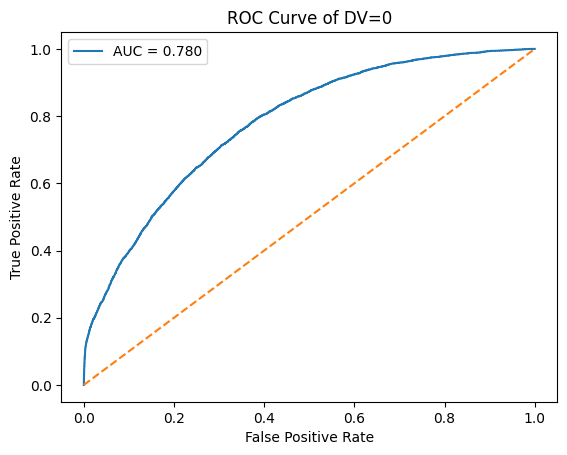

              precision    recall  f1-score   support

           0       0.30      0.72      0.43      4822
           1       0.93      0.69      0.79     25178

    accuracy                           0.69     30000
   macro avg       0.62      0.70      0.61     30000
weighted avg       0.83      0.69      0.73     30000

current model auc:0.780179
current model name:Best Random Search Model


In [74]:
model_summary(ml_search_v2, X_val, y_val, "Best Random Search Model")

In [61]:
best_model = ml_search_v2.best_estimator_

In [66]:
print("\nBest parameters:")
print(ml_search_v2.best_params_)


Best parameters:
{'sampler': 'passthrough', 'preprocess__num__drop_missing_cols__threshold': 80, 'preprocess__cat__drop_missing_cols__threshold': 60, 'model__subsample': 0.6, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0, 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=Non

## Pipeline name extraction

In [75]:


# ============================================================
# 1. Get best fitted pipeline pieces for ml_search_v2
# ============================================================

best_pipe = ml_search_v2.best_estimator_

preprocess = best_pipe.named_steps["preprocess"]
best_model = best_pipe.named_steps["model"]

print("Best pipeline:")
print(best_pipe)


# ============================================================
# 2. Get categorical feature names after:
#    Missing_val_dropper -> Imputer -> CategoricalFeatureSelector -> OneHotEncoder
# ============================================================

cat_pipeline = preprocess.named_transformers_["cat"]

cat_missing_dropper = cat_pipeline.named_steps["drop_missing_cols"]
cat_selector = cat_pipeline.named_steps["cat_selector"]
onehot = cat_pipeline.named_steps["onehot"]

cat_cols_original = np.array(Cat_train_columns, dtype=object)

# Columns dropped by Missing_val_dropper
cat_missing_dropped = getattr(cat_missing_dropper, "columns_to_drop", [])

print("\nOriginal categorical columns:")
print(cat_cols_original)

print("\nCategorical columns dropped by missingness:")
print(cat_missing_dropped)

# Keep categorical columns that survived Missing_val_dropper
kept_cat_after_missing = np.array([
    col for col in cat_cols_original
    if col not in cat_missing_dropped
], dtype=object)

print("\nCategorical columns kept after missingness dropper:")
print(kept_cat_after_missing)

# Columns dropped by CategoricalFeatureSelector
cat_selector_dropped = getattr(cat_selector, "columns_to_drop", [])

print("\nCategorical columns dropped by CategoricalFeatureSelector:")
print(cat_selector_dropped)

# If selector stores integer positions
if len(cat_selector_dropped) > 0 and isinstance(cat_selector_dropped[0], (int, np.integer)):
    kept_cat_cols = np.delete(kept_cat_after_missing, cat_selector_dropped)

# If selector stores column names
elif len(cat_selector_dropped) > 0 and isinstance(cat_selector_dropped[0], str):
    kept_cat_cols = np.array([
        col for col in kept_cat_after_missing
        if col not in cat_selector_dropped
    ], dtype=object)

# If nothing was dropped
else:
    kept_cat_cols = kept_cat_after_missing

print("\nFinal categorical columns going into OneHotEncoder:")
print(kept_cat_cols)

# OHE feature names
cat_feature_names = onehot.get_feature_names_out(kept_cat_cols)

print("\nNumber of OHE categorical features:")
print(len(cat_feature_names))

print("\nFirst 20 categorical feature names:")
print(cat_feature_names[:20])


# ============================================================
# 3. Get numerical feature names with real column names
# ============================================================

num_pipeline = preprocess.named_transformers_["num"]

print("\nNumerical pipeline:")
print(num_pipeline)

num_missing_dropper = num_pipeline.named_steps["drop_missing_cols"]

num_cols_original = np.array(numerical_train_columns, dtype=object)

# Columns dropped by Missing_val_dropper
num_missing_dropped = getattr(num_missing_dropper, "columns_to_drop", [])

print("\nOriginal numerical columns:")
print(num_cols_original)

print("\nNumerical columns dropped by missingness:")
print(num_missing_dropped)

# Numerical columns that survived Missing_val_dropper
num_cols_kept = np.array([
    col for col in num_cols_original
    if col not in num_missing_dropped
], dtype=object)

print("\nNumerical columns kept after missingness dropper:")
print(num_cols_kept)


# ============================================================
# 4. Build numerical feature names after imputation
# ============================================================

# Start with original numeric columns that survived missingness dropper
num_original_names = np.array([
    f"num__{col}" for col in num_cols_kept
], dtype=object)

# If your numeric pipeline uses SimpleImputer(add_indicator=True),
# add names for the missing indicator columns.
missing_indicator_names = np.array([], dtype=object)

if "imputer" in num_pipeline.named_steps:
    num_imputer = num_pipeline.named_steps["imputer"]

    if hasattr(num_imputer, "indicator_") and num_imputer.indicator_ is not None:
        missing_indicator_indices = num_imputer.indicator_.features_

        missing_indicator_names = np.array([
            f"missing_indicator__{num_cols_kept[i]}"
            for i in missing_indicator_indices
        ], dtype=object)

num_feature_names = np.concatenate([
    num_original_names,
    missing_indicator_names
])

print("\nNumber of original numeric feature names:")
print(len(num_original_names))

print("\nNumber of missing indicator feature names:")
print(len(missing_indicator_names))

print("\nTotal numerical feature names created:")
print(len(num_feature_names))


# ============================================================
# 5. Check numerical feature-name count against actual numeric output
# ============================================================

X_num_processed = num_pipeline.transform(X_train[numerical_train_columns])

print("\nActual numerical output shape:")
print(X_num_processed.shape)

print("\nNumerical feature names created:")
print(len(num_feature_names))

# Case A: numeric pipeline is dropper -> imputer/add_indicator -> scaler
if X_num_processed.shape[1] == len(num_feature_names):
    print("\nNumerical feature names match numeric output.")

# Case B: numeric pipeline also adds outlier flags for every numeric/imputed feature
elif X_num_processed.shape[1] == 2 * len(num_feature_names):
    print("\nDetected extra outlier-flag style features.")

    outlier_feature_names = np.array([
        f"outlier_flag__{name.replace('num__', '').replace('missing_indicator__', '')}"
        for name in num_feature_names
    ], dtype=object)

    num_feature_names = np.concatenate([
        num_feature_names,
        outlier_feature_names
    ])

    print("\nUpdated numerical feature names with outlier flags:")
    print(len(num_feature_names))

# Case C: numeric pipeline creates original numeric + outlier flags + missing indicators
elif X_num_processed.shape[1] == (2 * len(num_original_names) + len(missing_indicator_names)):
    print("\nDetected original numeric + outlier flags + missing indicators structure.")

    outlier_feature_names = np.array([
        f"outlier_flag__{col}"
        for col in num_cols_kept
    ], dtype=object)

    num_feature_names = np.concatenate([
        num_original_names,
        outlier_feature_names,
        missing_indicator_names
    ])

    print("\nUpdated numerical feature names with original/outlier/missing structure:")
    print(len(num_feature_names))

else:
    print("\nWARNING: Numerical feature names still do not match numeric output.")
    print("Numeric output columns:", X_num_processed.shape[1])
    print("Numeric names created:", len(num_feature_names))
    print("\nCheck your num_pipeline structure above.")
    raise ValueError("Could not reconstruct full numerical feature names from current numeric pipeline.")


# ============================================================
# 6. Check for remainder passthrough columns
# ============================================================

remainder_feature_names = np.array([], dtype=object)

for name, transformer, cols in preprocess.transformers_:
    if name == "remainder" and transformer == "passthrough":

        if len(cols) > 0 and isinstance(cols[0], (int, np.integer)):
            remainder_cols = np.array(X_train.columns, dtype=object)[cols]
        else:
            remainder_cols = np.array(cols, dtype=object)

        remainder_feature_names = np.array([
            f"remainder__{col}" for col in remainder_cols
        ], dtype=object)

print("\nNumber of remainder passthrough features:")
print(len(remainder_feature_names))

print("\nRemainder passthrough features:")
print(remainder_feature_names)


# ============================================================
# 7. Combine all feature names after preprocessing
# ============================================================

feature_names_after_preprocess = np.concatenate([
    cat_feature_names,
    num_feature_names,
    remainder_feature_names
])

X_processed = preprocess.transform(X_train)

print("\nShape after preprocessing:")
print(X_processed.shape)

print("\nNumber of feature names created:")
print(len(feature_names_after_preprocess))

print("\nDifference:")
print(X_processed.shape[1] - len(feature_names_after_preprocess))

assert X_processed.shape[1] == len(feature_names_after_preprocess), \
    "Feature names do not match processed data shape."

print("\nFeature names match processed data shape.")


# ============================================================
# 8. Final feature names used by ml_search_v2 model
# ============================================================

final_features = feature_names_after_preprocess

final_features_df = pd.DataFrame({
    "final_feature": final_features
})

print("\nNumber of final features used by model:")
print(len(final_features))

display(final_features_df)


# ============================================================
# 9. Feature importance / coefficients
# ============================================================

if hasattr(best_model, "coef_"):

    # Binary classification
    if best_model.coef_.ndim == 2 and best_model.coef_.shape[0] == 1:
        importance_df = pd.DataFrame({
            "feature": final_features,
            "coefficient": best_model.coef_[0]
        })

        importance_df["abs_importance"] = importance_df["coefficient"].abs()

        importance_df = importance_df.sort_values(
            "abs_importance",
            ascending=False
        )

    # Multiclass classification
    else:
        coef_abs_mean = np.mean(np.abs(best_model.coef_), axis=0)

        importance_df = pd.DataFrame({
            "feature": final_features,
            "mean_abs_coefficient": coef_abs_mean
        })

        importance_df = importance_df.sort_values(
            "mean_abs_coefficient",
            ascending=False
        )

elif hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": final_features,
        "importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

else:

    importance_df = pd.DataFrame({
        "feature": final_features
    })

print("\nTop final features:")
display(importance_df.head(30))

Best pipeline:
Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('drop_missing_cols',
                                                                   Missing_val_dropper(threshold=70)),
                                                                  ('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('cat_selector',
                                                                   CategoricalFeatureSelector()),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
        

,final_feature
0,term_60 months
1,sub_grade_A2
2,sub_grade_A3
3,sub_grade_A4
4,sub_grade_A5
...,...
184,num__Customer_history
185,num__loan_age_months
186,num__months_since_earliest_credit_line
187,num__current_balance_ratio



Top final features:


,feature,importance
187,num__current_balance_ratio,0.194840
129,num__last_fico_range_low,0.115681
2,sub_grade_A3,0.045450
1,sub_grade_A2,0.038611
3,sub_grade_A4,0.033766
4,sub_grade_A5,0.032256
0,term_60 months,0.030481
120,num__fico_range_low,0.021485
5,sub_grade_B1,0.019142
6,sub_grade_B2,0.017245


In [55]:
param_distributions_lr_v2 = [
    #Each dictionary value is for each model set up, like for example each differnt versions of Logistic regression are based on the different model penalties, and not all can use other model penalties
    # Logistic Regression
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        'sampler': [
            'passthrough',
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [LogisticRegression(max_iter=5000)],
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs', 'saga'],
        'model__class_weight': [None, 'balanced']
    },

    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        'sampler': [
            'passthrough',
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [LogisticRegression(max_iter=5000)],
        'model__penalty': ['l1'],
        'model__C': [0.001, 0.01, 0.1, 1, 10],
        'model__solver': ['saga'],
        'model__class_weight': [None, 'balanced']
    }
]

In [56]:
lr_search_v2 = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions_lr_v2,
    n_iter=5,
    scoring=f1_class_0,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

lr_search_v2.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [LogisticRegre...max_iter=5000)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l2'], ...}, {'model': [LogisticRegre...max_iter=5000)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1'], ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is 

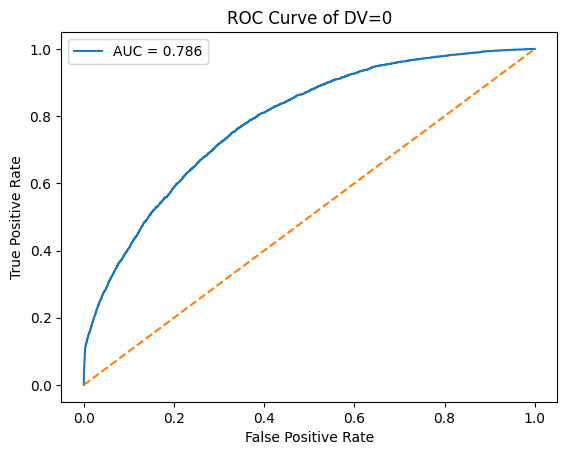

              precision    recall  f1-score   support

           0       0.76      0.14      0.24      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.85     30000
   macro avg       0.81      0.57      0.58     30000
weighted avg       0.84      0.85      0.81     30000

current model auc:0.785574
current model name:Best Random Search Model


In [57]:
model_summary(lr_search_v2, X_val, y_val, "Best Random Search Model")

In [1]:
from torch.optim import Adam
from skorch import NeuralNetClassifier

KeyboardInterrupt: 

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [54]:
class MLPClassifier(nn.Module):
    def __init__(self,dropout=0.30):
        super().__init__()

        # LazyLinear automatically figures out input_dim on first batch
        self.input_to_hidden = nn.LazyLinear(16)
        
        self.hidden_to_hidden_1 = nn.Linear(16, 32)
        self.hidden_to_hidden_2 = nn.Linear(32, 64)
        self.hidden_to_hidden_3 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(p=dropout)
        self.hidden_to_output = nn.Linear(128,2)


    def forward(self, X):
        hidden = torch.relu(self.input_to_hidden(X))
        hidden = self.dropout(hidden)

        hidden = torch.relu(self.hidden_to_hidden_1(hidden))
        hidden = self.dropout(hidden)

        hidden = torch.relu(self.hidden_to_hidden_2(hidden))
        hidden = self.dropout(hidden)

        hidden = torch.relu(self.hidden_to_hidden_3(hidden))
        hidden = self.dropout(hidden)

        logits = self.hidden_to_output(hidden)
        return logits

In [55]:
net = NeuralNetClassifier(
    module=MLPClassifier,
    module__dropout=0.3,

    criterion=nn.CrossEntropyLoss,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.01,

    max_epochs=500,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1
)

In [56]:
from sklearn.preprocessing import FunctionTransformer

In [57]:
nn_pipe = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net)
])

In [58]:
from scipy.stats import loguniform, uniform

param_dist = {
    "model__optimizer__lr": loguniform(1e-4, 1e-2),
    "model__optimizer__weight_decay": loguniform(1e-5, 1e-1),
    "model__module__dropout": uniform(0.1, 0.4)  # tries 0.1 to 0.5
}

random_search = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train.astype("int64"))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5208       0.8393        0.3567  3.0389
      2        0.3112       0.8224        0.2290  2.9133
      3        0.2090       0.9703        0.1341  2.8382
      4        0.1526       0.9710        0.1072  2.8725
      5        0.1366       0.9806        0.0776  2.8751
      6        0.1257       0.9826        0.0658  3.0542
      7        0.0934       0.9843        0.0592  2.9177
      8        0.0854       0.9885        0.0496  2.8383
      9        0.0810       0.9831        0.0593  3.0376
     10        0.0834       0.9881        0.0454  2.8963
     11        0.0751       0.9887        0.0452  2.8179
     12        0.0773       0.9838        0.0529  2.8371
     13        0.0753       0.9875        0.0469  2.8671
     14        0.0732       0.9891        0.0430  2.7985
     15        0.0687      

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__module__dropout': <scipy.stats....0018A5C3F7100>, 'model__optimizer__lr': <scipy.stats....0018A5C40FED0>, 'model__optimizer__weight_decay': <scipy.stats....0018A5C3F6780>}"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [59]:
best_model = random_search.best_estimator_

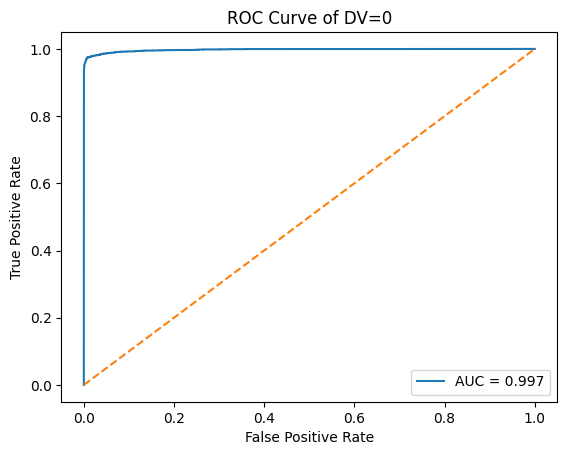

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4822
           1       0.99      1.00      0.99     25178

    accuracy                           0.99     30000
   macro avg       0.99      0.97      0.98     30000
weighted avg       0.99      0.99      0.99     30000

current model auc:0.997487
current model name:Best Random Search Model


In [60]:
model_summary(best_model, X_val, y_val, "Best Random Search Model")

“Given the borrower and loan information available now, can we classify whether the loan is currently in good standing or risky?”

## ------------------------